In [3]:
import xarray as xr

GRID_REGISTRY = {
    "EEA_1km": {
        "crs": "EPSG:3035",
        "resolution": 1000, 
        "bounds": (2000000, 1000000, 6000000, 5500000) # (min_x, min_y, max_x, max_y)
    },
    "Global_EqualArea_1km": {
        "crs": "EPSG:6933",
        "resolution": 1000,
        "bounds": (-17367530, -7314540, 17367530, 7314540)
    },
    "Global_WGS84_30sec": {
        "crs": "EPSG:4326",
        "resolution": 0.008333333333333333, # ~1km at the equator (30 arc-seconds)
        "bounds": (-180.0, -90.0, 180.0, 90.0) # (min_lon, min_lat, max_lon, max_lat)
    }
}
chelsa_datatree = xr.open_datatree("out/techDemo_cube/techDemo.nc", engine="netcdf4")
chelsa_month = chelsa_datatree["dynamic"]["chelsa_month"].ds.copy()
chelsa_month

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 12, lat: 94, long: 154)
Coordinates:
  * time     (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
  * lat      (lat) float64 752B 51.45 51.44 51.43 51.43 ... 50.69 50.68 50.68
  * long     (long) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
Data variables:
    clt      (time, lat, long) float64 1MB ...
    cmi      (time, lat, long) int16 347kB ...
    hurs     (time, lat, long) uint16 347kB ...
    pet      (time, lat, long) uint16 347kB ...
    pr       (time, lat, long) int32 695kB ...
    rsds     (time, lat, long) uint16 347kB ...
    sfcWind  (time, lat, long) uint16 347kB ...
    tas      (time, lat, long) int32 695kB ...
    tasmax   (time, lat, long) int32 695kB ...
    tasmin   (time, lat, long) int32 695kB ...
    vpd      (time, lat, long) uint16 347kB ...

In [4]:
import numpy as np
import rioxarray

def prep_for_reprojection(ds, default_crs="EPSG:4326"):
    """
    Validates and sanitizes an xarray Dataset/DataArray to ensure it 
    meets all strict rioxarray/GDAL criteria for reprojection.
    """
    # Work on a copy to avoid mutating the original dataset unintentionally
    ds = ds.copy()

    # --- 1. Clean Metadata & Standardize Spatial Dimensions ---
    # Drop confusing metadata from other libraries
    if "spatial_ref" in ds.variables:
        ds = ds.drop_vars("spatial_ref")
    ds.encoding.clear()
    
    # Auto-detect and rename horizontal/vertical axes
    dim_map = {}
    for dim in ds.dims:
        dim_str = str(dim).lower()
        if dim_str in ['lon', 'longitude', 'long']:
            dim_map[dim] = 'x'
        elif dim_str in ['lat', 'latitude']:
            dim_map[dim] = 'y'
            
    if dim_map:
        ds = ds.rename(dim_map)
        
    ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y")

    # --- 2 & 4. Valid CRS & Axis Order ---
    # If no CRS exists, assume standard unprojected Lon/Lat
    if ds.rio.crs is None:
        ds = ds.rio.write_crs(default_crs)
    # If it strictly says EPSG:4326, override to OGC:CRS84 to prevent the GDAL axis-flip bug
    elif ds.rio.crs.to_string() == "EPSG:4326":
        ds = ds.rio.write_crs("OGC:CRS84")

    # --- 3. Perfectly Uniform Grid Spacing ---
    # Erase microscopic floating-point drift in the coordinate arrays
    ds = ds.assign_coords(
        x=np.linspace(float(ds.x.values[0]), float(ds.x.values[-1]), len(ds.x)),
        y=np.linspace(float(ds.y.values[0]), float(ds.y.values[-1]), len(ds.y))
    )

    # --- 5. Data Types and NoData Handling ---
    # Cast to float32 to support np.nan and prevent integer math clipping during resampling
    ds = ds.astype("float32")
    
    # rioxarray requires writing nodata to each variable individually in a Dataset
    if isinstance(ds, xr.Dataset):
        for var in ds.data_vars:
            # Skip non-spatial variables if any exist (like a 1D time array)
            if 'x' in ds[var].dims and 'y' in ds[var].dims:
                ds[var] = ds[var].rio.write_nodata(np.nan)
    else:
        # If it's a single DataArray
        ds = ds.rio.write_nodata(np.nan)

    return ds

In [5]:
prepped_ds = prep_for_reprojection(chelsa_month)
prepped_ds.rio.crs

✅ Dataset successfully sanitized and prepped for reprojection.


CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

# Affine transform method

This method is purely mathematical. It does not create a template dataset; instead, it calculates the strict mathematical parameters (Shape and Transform) that GDAL needs to execute the reprojection.

The Workflow:

Find Source Bounds: Extract the bounding box of your original raster.

Project Bounds: Convert that bounding box into the target CRS (e.g., EPSG:3035). At this stage, the coordinates will be messy floating-point numbers.

Snap to Master Grid: Use mathematical floor and ceil operations, referencing the master grid's origin, to push those messy coordinates outward to the nearest perfect 1000m grid line.

Calculate Parameters: Calculate how many pixels wide/high this snapped box is, and define its top-left anchor point (the Affine Transform).

In [37]:
import numpy as np
from rasterio.warp import transform_bounds
from rasterio.transform import from_origin
from rasterio.enums import Resampling

def affine_reproject(ds, grid_name, resample_keyword="bilinear"):
    """
    Calculates strict shape and transform parameters for rioxarray. Subsequently reprojects the 
    """
    spec = GRID_REGISTRY[grid_name]
    target_crs = spec["crs"]
    res = spec["resolution"]
    master_minx, master_miny, _, _ = spec["bounds"]

    # 1 & 2. Get bounds and project them to the target CRS
    # Extract the coordinates of the bounds of the dataset
    src_minx, src_miny, src_maxx, src_maxy = ds.rio.bounds()
    # Calculate the destination that the bounds will have in the target CRS system
    dst_minx, dst_miny, dst_maxx, dst_maxy = transform_bounds(
        ds.rio.crs, target_crs, src_minx, src_miny, src_maxx, src_maxy
    )

    # 3. Snap to the Master Grid lines
    snap_minx = master_minx + np.floor((dst_minx - master_minx) / res) * res
    snap_maxx = master_minx + np.ceil((dst_maxx - master_minx) / res) * res
    snap_maxy = master_miny + np.ceil((dst_maxy - master_miny) / res) * res
    snap_miny = master_miny + np.floor((dst_miny - master_miny) / res) * res

    # 4. Calculate final parameters
    width = int(round((snap_maxx - snap_minx) / res))
    height = int(round((snap_maxy - snap_miny) / res))
    
    # from_origin requires (Left, Top, X_resolution, Y_resolution)
    transform = from_origin(snap_minx, snap_maxy, res, res)

    params = {"shape": (height, width), "transform": transform, "crs": target_crs}

    RESAMPLING_METHODS = {"nearest": Resampling.nearest,
                          "bilinear": Resampling.bilinear,
                          "cubic": Resampling.cubic,
                          "average": Resampling.average,
                          "mode": Resampling.mode,
                          "sum": Resampling.sum,
                          "max": Resampling.max,
                          "min": Resampling.min,}
    
    resampler = RESAMPLING_METHODS.get(resample_keyword, Resampling.nearest)
    print(resample_keyword)
    result = ds.rio.reproject(params["crs"], 
                              shape=params["shape"],
                              transform=params["transform"],
                              resampling=resampler)
    return result

In [39]:
RESAMPLING_METHODS = {"nearest": Resampling.nearest,
                          "bilinear": Resampling.bilinear,
                          "cubic": Resampling.cubic,
                          "average": Resampling.average,
                          "mode": Resampling.mode,
                          "sum": Resampling.sum,
                          "max": Resampling.max,
                          "min": Resampling.min,}

RESAMPLING_METHODS.get("bilinear", Resampling.nearest)

<Resampling.bilinear: 1>

In [38]:
reproject_EEA = affine_reproject(prepped_ds,"EEA_1km")
reproject_GEA = affine_reproject(prepped_ds,"Global_EqualArea_1km")

bilinear
bilinear


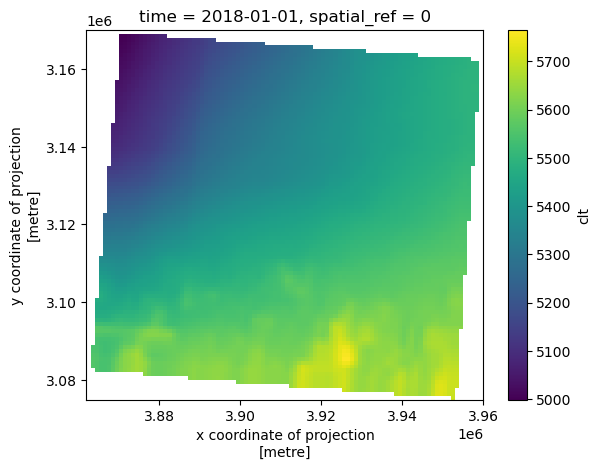

In [31]:
reproject_EEA["clt"].sel(time="2018-01-01", method="nearest").plot()

In [34]:
reproject_GEA

<xarray.Dataset> Size: 4MB
Dimensions:      (x: 125, y: 65, time: 12)
Coordinates:
  * x            (x) float64 1kB 3.39e+05 3.4e+05 3.41e+05 ... 4.62e+05 4.63e+05
  * y            (y) float64 520B 5.733e+06 5.732e+06 ... 5.67e+06 5.669e+06
  * time         (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
    spatial_ref  int64 8B 0
Data variables:
    clt          (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    cmi          (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    hurs         (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    pet          (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    pr           (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    rsds         (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    sfcWind      (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    tas          (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    tasmax       (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    tasmin       (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan
    vpd          (time, y, x) float32 390kB nan nan nan nan ... nan nan nan nan

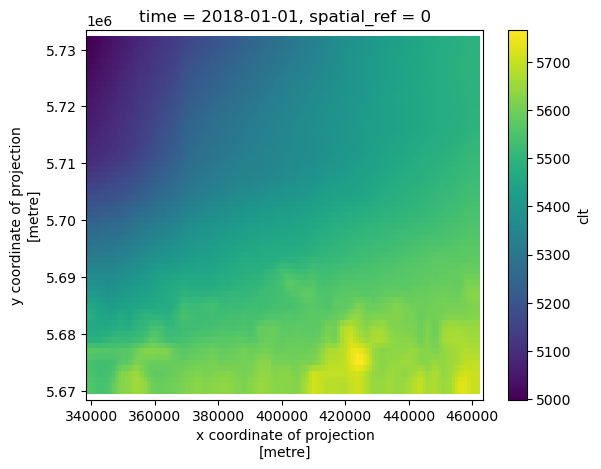

In [32]:
reproject_GEA["clt"].sel(time="2018-01-01", method="nearest").plot()

In [76]:
reprojected_ds = prepped_ds.rio.reproject(params["crs"], shape=params["shape"], transform=params["transform"])
reprojected_ds

<xarray.Dataset> Size: 5MB
Dimensions:      (x: 98, y: 95, time: 12)
Coordinates:
  * x            (x) float64 784B 3.862e+06 3.864e+06 ... 3.958e+06 3.96e+06
  * y            (y) float64 760B 3.17e+06 3.168e+06 ... 3.076e+06 3.076e+06
  * time         (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
    spatial_ref  int64 8B 0
Data variables:
    clt          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    cmi          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    hurs         (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    pet          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    pr           (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    rsds         (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    sfcWind      (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    tas          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    tasmax       (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    tasmin       (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    vpd          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan

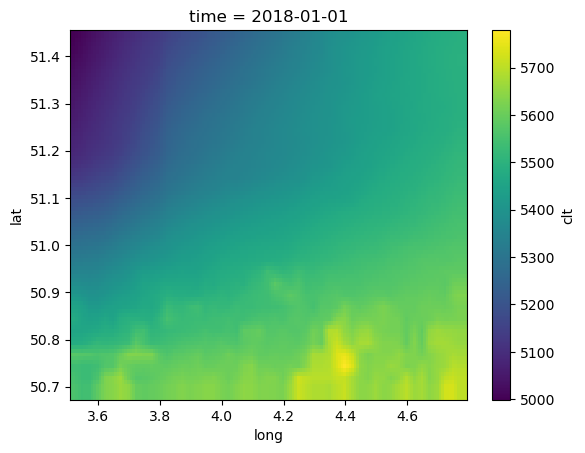

In [88]:
chelsa_month["clt"].sel(time="2018-01-01", method="nearest").plot()

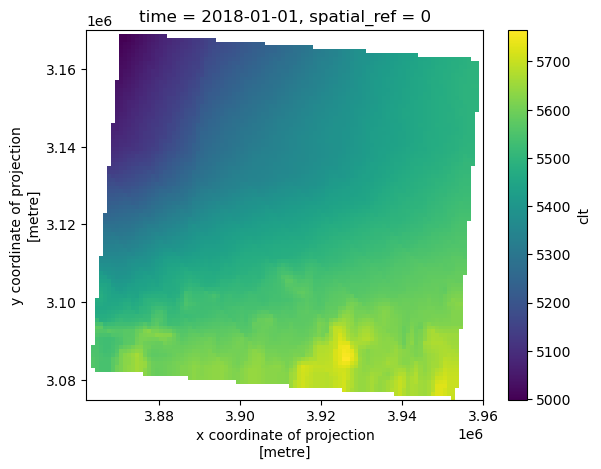

In [87]:
reprojected_ds["clt"].sel(time="2018-01-01", method="nearest").plot()

In [77]:
da_2d = prepped_ds["pr"].isel(time=0)
da_2d

<xarray.DataArray 'pr' (y: 94, x: 154)> Size: 58kB
array([[8577., 8590., 8598., ..., 9641., 9644., 9654.],
       [8588., 8592., 8600., ..., 9630., 9632., 9642.],
       [8593., 8593., 8602., ..., 9619., 9624., 9630.],
       ...,
       [8131., 8150., 8157., ..., 6126., 6110., 6082.],
       [8208., 8217., 8218., ..., 6145., 6118., 6086.],
       [8308., 8302., 8297., ..., 6167., 6132., 6098.]],
      shape=(94, 154), dtype=float32)
Coordinates:
    time         datetime64[ns] 8B 2018-01-01
    spatial_ref  int64 8B 0
  * x            (x) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
  * y            (y) float64 752B 51.45 51.44 51.43 51.43 ... 50.69 50.68 50.68
Attributes:
    _FillValue:  nan

In [78]:
reprojected_da = da_2d.rio.reproject(
    params["crs"], 
    shape=params["shape"], 
    transform=params["transform"],
    resampling=Resampling.bilinear
)
reprojected_da

<xarray.DataArray 'pr' (y: 95, x: 98)> Size: 37kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(95, 98), dtype=float32)
Coordinates:
  * x            (x) float64 784B 3.862e+06 3.864e+06 ... 3.958e+06 3.96e+06
  * y            (y) float64 760B 3.17e+06 3.168e+06 ... 3.076e+06 3.076e+06
    time         datetime64[ns] 8B 2018-01-01
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

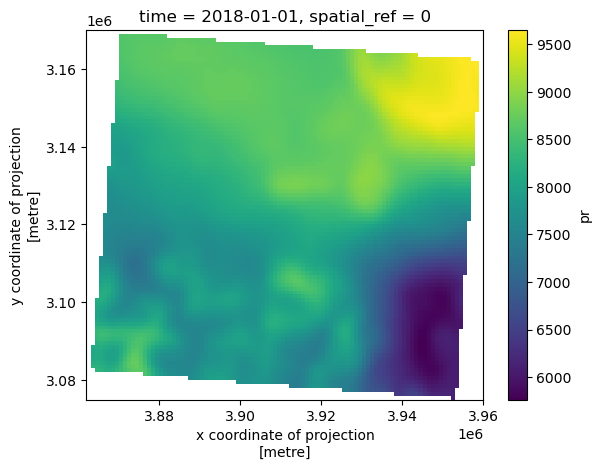

In [82]:
reprojected_da.plot()

In [79]:
import xarray as xr
import numpy as np
import rioxarray
from rasterio.enums import Resampling

# 1. Extract the raw naked numbers (stripping ALL NetCDF metadata)
raw_values = prepped_ds["pr"].isel(time=0).values
x_coords = prepped_ds.x.values
y_coords = prepped_ds.y.values

# 2. Rebuild a perfectly clean DataArray from scratch
clean_da = xr.DataArray(
    data=raw_values,
    dims=("y", "x"),
    coords={"x": x_coords, "y": y_coords}
)

# 3. Explicitly define the CRS and NoData (No hidden conflicts!)
clean_da = clean_da.rio.write_crs("EPSG:4326")
clean_da = clean_da.rio.set_spatial_dims(x_dim="x", y_dim="y")
clean_da = clean_da.rio.write_nodata(np.nan)

# 4. Perform the reprojection using the parameters we already calculated
print("Reprojecting clean numpy array...")
reprojected_clean = clean_da.rio.reproject(
    params["crs"],
    shape=params["shape"],
    transform=params["transform"],
    resampling=Resampling.bilinear
)

# 5. The moment of truth
max_val = np.nanmax(reprojected_clean.values)
if np.isnan(max_val):
    print("❌ Test Failed: Still NaNs. The spatial math is fundamentally broken.")
else:
    print(f"✅ SUCCESS! Max precipitation value: {max_val}")

Reprojecting clean numpy array...
✅ SUCCESS! Max precipitation value: 9648.705078125


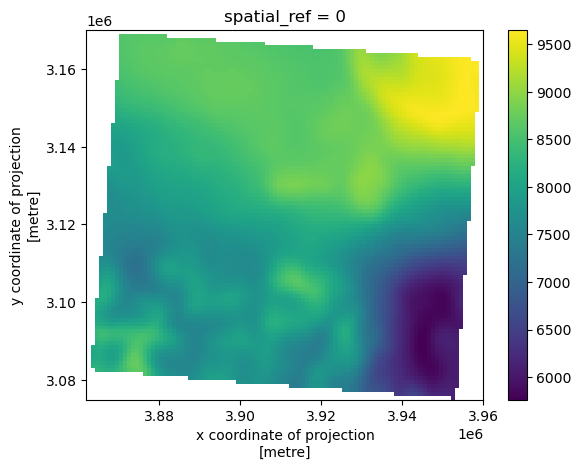

In [81]:
reprojected_clean.plot()

# geobox method

This method is object-oriented. Instead of doing raw math, you build a "virtual" map of the entire predefined CRS, and then slice a piece out of it.

The Workflow:

Create Master GeoBox: Instantiate a massive GeoBox object that represents the entire predefined grid (e.g., all of Europe). This takes zero memory because it is just a metadata object.

Get Source Polygon: Extract the exact geographical footprint (extent) of your input raster and project it to the target CRS.

Slice the Master: Use that projected footprint to "cookie-cut" the master GeoBox. odc-geo automatically handles the grid-snapping math behind the scenes.

Generate Template: Ask the sliced GeoBox to generate an empty xarray dataset perfectly matching those dimensions.

In [11]:
from odc.geo.geobox import GeoBox
from odc.geo.geom import BoundingBox
from odc.geo.xr import xr_zeros

def get_geobox_template(ds, grid_name):
    """Slices a master geobox to create a physical xarray template."""
    spec = GRID_REGISTRY[grid_name]
    target_crs = spec["crs"]
    
    # 1. Create the massive master grid
    master_gbox = GeoBox.from_bbox(
        spec["bounds"], crs=target_crs, resolution=spec["resolution"]
    )
    
    # 2. Extract input bounds and project them
    # BoundingBox requires (minx, miny, maxx, maxy)
    src_bbox = BoundingBox(*ds.rio.bounds(), crs=ds.rio.crs)
    projected_bbox = src_bbox.to_crs(target_crs)
    
    # 3. Slice the master grid! (This handles the snapping automatically)
    sub_gbox = master_gbox[projected_bbox]
    
    # 4. Generate an empty xarray DataArray from the sliced geobox
    template = xr_zeros(sub_gbox)    
    
    # Attach standard rioxarray metadata to the template
    template = template.rio.write_crs(target_crs)
    template = template.rio.set_spatial_dims(x_dim="x", y_dim="y")
    
    return template
    
# result = my_raster.rio.reproject_match(template)

In [12]:
template = get_geobox_template(prepped_ds, "EEA_1km")
template

<xarray.DataArray (y: 95, x: 98)> Size: 74kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(95, 98))
Coordinates:
  * y            (y) float64 760B 3.17e+06 3.168e+06 ... 3.076e+06 3.076e+06
  * x            (x) float64 784B 3.862e+06 3.864e+06 ... 3.958e+06 3.96e+06
    spatial_ref  int64 8B 0

In [13]:
gb_reprojected_ds =  prepped_ds.rio.reproject_match(template)
gb_reprojected_ds

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 12, x: 98, y: 95)
Coordinates:
  * time         (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
    spatial_ref  int64 8B 0
  * x            (x) float64 784B 3.862e+06 3.864e+06 ... 3.958e+06 3.96e+06
  * y            (y) float64 760B 3.17e+06 3.168e+06 ... 3.076e+06 3.076e+06
Data variables:
    clt          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    cmi          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    hurs         (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    pet          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    pr           (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    rsds         (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    sfcWind      (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    tas          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    tasmax       (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    tasmin       (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan
    vpd          (time, y, x) float32 447kB nan nan nan nan ... nan nan nan nan

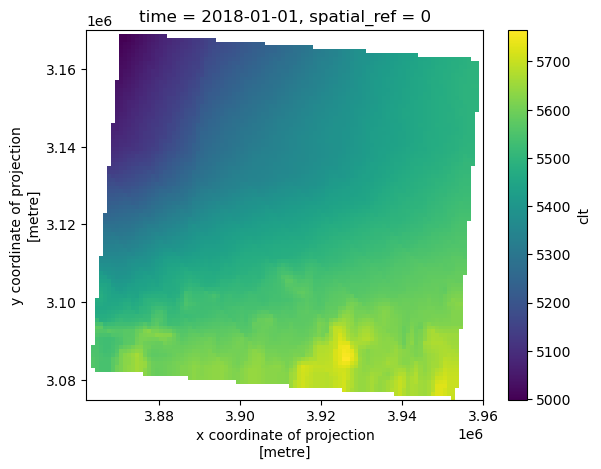

In [15]:
gb_reprojected_ds["clt"].sel(time="2018-01-01").plot()

In [20]:
gb_reprojected_ds.to_netcdf("reprojected_chelsa_month.nc", format="NETCDF4", mode="w", engine="netcdf4", decode_coords="all")

TypeError: Dataset.to_netcdf() got an unexpected keyword argument 'decode_coords'

In [17]:
ls

 Volume in drive C is OS
 Volume Serial Number is 1C25-B250

 Directory of C:\Users\niels\Documents\Repositories\BmC\scripts\harmonization

26/02/2026  10:08    <DIR>          .
17/02/2026  10:18    <DIR>          ..
17/02/2026  10:21    <DIR>          .ipynb_checkpoints
24/02/2026  14:47         1.175.249 gbif harmonization.ipynb
26/02/2026  10:08           558.411 Harmonization.ipynb
17/02/2026  10:23    <DIR>          out
26/02/2026  10:08         4.941.752 reprojected_chelsa_month.nc
18/02/2026  14:07    <DIR>          test
24/02/2026  14:40         2.476.347 test.csv
               4 File(s)      9.151.759 bytes
               5 Dir(s)  227.740.557.312 bytes free


In [18]:
gb_reprojected_ds.rio.crs

CRS.from_wkt('PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3035"]]')